In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [6]:
def plot_r_squared(horizon, result_path = '../results', save_path = '../tables'):
    """
    Plot out-of-sample R^2 for different lambda settings
    
    Parameters:
    -----------
    horizon : str
        Prediction horizon prefix in filename (e.g., 'approx', 'predict_12months')
    """
    # Set academic-style plotting parameters
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'font.size': 15,
        'axes.linewidth': 0.8,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.major.width': 0.8,
        'ytick.major.width': 0.8,
        'lines.linewidth': 2,
        'lines.markersize': 6,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.5
    })
    
    whole_periods = pd.DataFrame()

    for file in os.listdir(result_path):
        if file.startswith(horizon) and file.endswith('.csv') and not file.endswith('mse.csv'):
            weight_lambda = float(file.split(f'{horizon}_')[1].split('.csv')[0])
            path = os.path.join(result_path, file)
            result = pd.read_csv(path)
            whole_periods[weight_lambda] = result['Whole periods']

    whole_periods.index = result['Unnamed: 0']
    whole_periods.loc["Consensus average", 0.000] = np.nan
    whole_periods = whole_periods.reindex(sorted(whole_periods.columns, key=float), axis=1)

    display(whole_periods)
    whole_periods.T.to_csv(f'{save_path}/{horizon}_r_squared.csv')

    # Create separate plots for asset returns and consensus variables
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Define academic color palette
    colors = ['#2E86AB', '#A23B72']  # Professional blue and burgundy
    
    # Plot 1: Asset Returns
    ax1.plot(whole_periods.columns, whole_periods.iloc[-1], '--', 
             color=colors[0], linewidth=2, markersize=6, 
             markerfacecolor=colors[0], markeredgecolor='black', markeredgewidth=0.5)
    ax1.grid(True, alpha=0.3, linewidth=0.5)
    ax1.set_xlabel('Hyperparameter (λ)')
    ax1.set_ylabel('Out-of-Sample R² (%)')
    ax1.set_title('Asset Returns', pad=15)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # Plot 2: Consensus Variables
    ax2.plot(whole_periods.columns, whole_periods.iloc[-2], '--', 
             color=colors[1], linewidth=2, markersize=6,
             markerfacecolor=colors[1], markeredgecolor='black', markeredgewidth=0.5)
    ax2.grid(True, alpha=0.3, linewidth=0.5)
    ax2.set_xlabel('Hyperparameter (λ)')
    ax2.set_ylabel('Out-of-Sample R² (%)')
    ax2.set_title('Consensus Variables', pad=15)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()
    plt.close()

In [14]:
def load_r2_data_and_best_lambda(horizon, columns):
    lambda_values = []
    data_dict = {}
    r_squared_by_lambda = {}
    for file in os.listdir('../results'):
        if file.startswith(horizon) and file.endswith('.csv') and not file.endswith('mse.csv'):
            weight_lambda = float(file.split(f'{horizon}_')[1].split('.csv')[0])
            lambda_values.append(weight_lambda)
            path = os.path.join('../results', file)
            result = pd.read_csv(path)
            data_dict[weight_lambda] = result
            r_squared_by_lambda[weight_lambda] = data_dict[weight_lambda]['Whole periods'].iloc[-1]
    non_zero_lambdas = {k: v for k, v in r_squared_by_lambda.items() if k != 0.0}
    best_lambda = max(non_zero_lambdas, key=non_zero_lambdas.get)
    return data_dict, r_squared_by_lambda, best_lambda

def calculate_r2_summaries(columns, index_name, data_dict, r_squared_by_lambda, best_lambda):
    summary_df = pd.DataFrame({
        'lambda': [0.0, best_lambda, 'improvement'],
        'R_squared': [
            r_squared_by_lambda[0.0],
            r_squared_by_lambda[best_lambda],
            r_squared_by_lambda[best_lambda] - r_squared_by_lambda[0.0]
        ]
    })
    naive_returns = data_dict[0.0].iloc[-1][columns]
    best_returns = data_dict[best_lambda].iloc[-1][columns]
    period_comparison_df = pd.DataFrame({
        'Period': [period_name.split('~')[0][:4] for period_name in index_name],
        'Naive_R2': [naive_returns[col] for col in columns],
        'Best_R2': [best_returns[col] for col in columns],
        'Diff': [best_returns[col] - naive_returns[col] for col in columns]
    })
    improved_periods = []
    declined_periods = []
    for col, period_name in zip(columns, index_name):
        naive_r2 = naive_returns[col]
        best_r2 = best_returns[col]
        improvement = best_r2 - naive_r2
        if improvement > 0:
            improved_periods.append((period_name.split('~')[0][:4], improvement))
        elif improvement < 0:
            declined_periods.append((period_name.split('~')[0][:4], improvement))
    improved_periods_df = pd.DataFrame(improved_periods, columns=['Period', 'Improvement'])
    declined_periods_df = pd.DataFrame(declined_periods, columns=['Period', 'Decline'])
    summary_data = {
        'Average Improvement': [sum(imp for _, imp in improved_periods) / len(improved_periods) if improved_periods else 0],
        'Average Decline': [sum(decl for _, decl in declined_periods) / len(declined_periods) if declined_periods else 0],
        'Total Periods': [len(columns)],
        'Improvement Rate (%)': [len(improved_periods)/len(columns)*100 if columns else 0]
    }
    summary_stats_df = pd.DataFrame(summary_data)
    return summary_df, period_comparison_df, improved_periods_df, declined_periods_df, summary_stats_df, best_lambda

def save_r2_results_to_excel(period_comparison_df, improved_periods_df, declined_periods_df, summary_stats_df, summary_df, filename):
    with pd.ExcelWriter(filename) as writer:
        period_comparison_df.to_excel(writer, sheet_name='Period_Comparison', index=False)
        improved_periods_df.to_excel(writer, sheet_name='Improved_Periods', index=False)
        declined_periods_df.to_excel(writer, sheet_name='Declined_Periods', index=False)
        summary_stats_df.to_excel(writer, sheet_name='Summary_Stats', index=False)
        summary_df.to_excel(writer, sheet_name='R2_Summary', index=False)

def plot_r2_comparison(columns, index_name, data_dict, best_lambda):
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'font.size': 15,
        'axes.linewidth': 0.8,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.major.width': 0.8,
        'ytick.major.width': 0.8,
        'lines.linewidth': 2,
        'lines.markersize': 6,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.5
    })

    selected_lambdas = [0.0, best_lambda]
    n_plots = len(selected_lambdas)
    fig_widths = [5, 8]
    fig, axes = plt.subplots(1, n_plots, figsize=(sum(fig_widths), 6), gridspec_kw={'width_ratios': fig_widths})
    if n_plots == 1:
        axes = [axes]
    colors = ['#2E86AB', '#A23B72']
    for idx, weight_lambda in enumerate(selected_lambdas):
        ax = axes[idx]
        result = data_dict[weight_lambda]
        index = np.arange(len(columns))
        if weight_lambda == 0.0:
            bar_width = 0.5
            ax.bar(index, result.iloc[-1][columns],
                        bar_width, label='Asset Returns',
                        color=colors[0], alpha=0.8, edgecolor='black', linewidth=0.5)
        else:
            bar_width = 0.35
            # Asset Returns - 대각선 패턴으로 채우기
            ax.bar(index - bar_width/2, result.iloc[-1][columns],
                        bar_width, label='Asset Returns',
                        color=colors[0], alpha=0.8, edgecolor='black', linewidth=0.5,
                        hatch='////')
            # Consensus Variables - 점 패턴으로 채우기
            ax.bar(index + bar_width/2, result.iloc[-2][columns],
                        bar_width, label='Consensus Variables',
                        color=colors[1], alpha=0.8, edgecolor='black', linewidth=0.5,
                        hatch='....')
        
        # y=0.0에 진한 검정색 선 추가
        ax.axhline(y=0.0, color='black', linestyle='-', linewidth=2, alpha=0.8)
        
        ax.set_xticks(index)
        ax.set_xticklabels([name.split('~')[0][:4] for name in index_name], rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3, linewidth=0.5)
        if weight_lambda == 0.0:
            ax.set_title('Naive Neural Network (λ=0)', pad=14)
        else:
            ax.set_title(f'Best Model (λ={best_lambda:.3f})', pad=14)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(frameon=True, fancybox=False, shadow=False,
                     edgecolor='black', framealpha=0.9, fontsize=15, loc='upper left')
        all_bar_values = []
        for weight_lambda2 in selected_lambdas:
            result2 = data_dict[weight_lambda2]
            if weight_lambda2 == 0.0:
                all_bar_values.extend(list(result2.iloc[-1][columns]))
            else:
                all_bar_values.extend(list(result2.iloc[-1][columns]))
                all_bar_values.extend(list(result2.iloc[-2][columns]))
        y_min, y_max = min(all_bar_values), max(all_bar_values)
        y_range = y_max - y_min
        ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)
        ax.tick_params(axis='x', pad=6)
        ax.set_xlabel('Testing Period Start Year', fontsize=18)
        ax.set_ylabel('Out-of-Sample R² (%)', fontsize=18)
    plt.tight_layout()
    plt.show()
    plt.close()

def plot_r_squared_by_period(columns, index_name, horizon):
    """
    Plot out-of-sample R^2 of predicting consensus variables and asset returns for different testing periods
    Compare naive neural network (λ=0) with the best performing model
    """
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'font.size': 15,
        'axes.linewidth': 0.8,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.major.width': 0.8,
        'ytick.major.width': 0.8,
        'lines.linewidth': 1.2,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.5
    })
    data_dict, r_squared_by_lambda, best_lambda = load_r2_data_and_best_lambda(horizon, columns)
    summary_df, period_comparison_df, improved_periods_df, declined_periods_df, summary_stats_df, best_lambda = calculate_r2_summaries(
        columns, index_name, data_dict, r_squared_by_lambda, best_lambda)
    filename = f'../tables/{horizon}_r2_analysis_summary.xlsx'
    save_r2_results_to_excel(period_comparison_df, improved_periods_df, declined_periods_df, summary_stats_df, summary_df, filename)
    plot_r2_comparison(columns, index_name, data_dict, best_lambda)

### Average R-Squared


Plotting R² for 1-month prediction horizon


,0.000,0.005,0.010,0.015,0.020,0.025,0.030,0.035,0.040,0.045,...,0.775,0.800,0.825,0.850,0.875,0.900,0.925,0.950,0.975,1.000
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
EPS forecast revision,-1.29,0.080000,0.230000,0.470000,0.81,1.19,1.560000,1.890000,2.210000,2.53,...,5.420000,5.420000,5.450000,5.460000,5.460000,5.470000,5.470000,5.46,5.460000,5.460000
Change in recommendation,-1.00,-0.040000,0.010000,0.020000,0.03,0.02,0.020000,0.040000,0.040000,0.02,...,0.090000,0.090000,0.090000,0.090000,0.080000,0.070000,0.070000,0.07,0.070000,0.070000
Change in Forecast and Accrual,-6.12,0.200000,0.480000,0.830000,1.16,1.52,1.840000,2.100000,2.320000,2.62,...,5.270000,5.260000,5.260000,5.280000,5.270000,5.270000,5.270000,5.27,5.270000,5.270000
Long-vs-short EPS forecasts,-0.94,0.210000,0.580000,1.100000,1.71,2.38,3.010000,3.650000,4.110000,4.71,...,9.930000,9.950000,9.990000,10.040000,10.050000,10.040000,10.050000,10.06,10.050000,10.070000
Analyst earnings per share,-1.47,3.470000,6.570000,10.470000,15.52,20.73,25.170000,29.410000,33.530000,38.03,...,78.930000,79.060000,79.200000,79.330000,79.430000,79.500000,79.600000,79.65,79.740000,79.810000
EPS Forecast Dispersion,-1.54,1.210000,2.450000,3.850000,5.84,7.94,10.610000,13.210000,15.190000,18.02,...,44.480000,44.620000,44.720000,44.810000,44.890000,44.980000,45.080000,45.15,45.250000,45.340000
Earnings forecast revisions,-0.58,0.490000,0.990000,1.740000,2.63,3.50,4.190000,4.930000,5.260000,6.10,...,18.570000,18.660000,18.730000,18.800000,18.860000,18.970000,19.070000,19.13,19.230000,19.270000
Analyst Value,-0.78,1.710000,2.860000,4.190000,5.88,7.78,9.880000,12.100000,13.520000,15.76,...,42.010000,42.160000,42.260000,42.370000,42.480000,42.650000,42.750000,42.85,42.960000,43.060000
Analyst Optimism,-1.43,0.810000,1.790000,3.230000,5.12,7.05,9.350000,11.840000,14.120000,16.70,...,43.210000,43.340000,43.480000,43.630000,43.730000,43.830000,43.930000,44.00,44.120000,44.200000


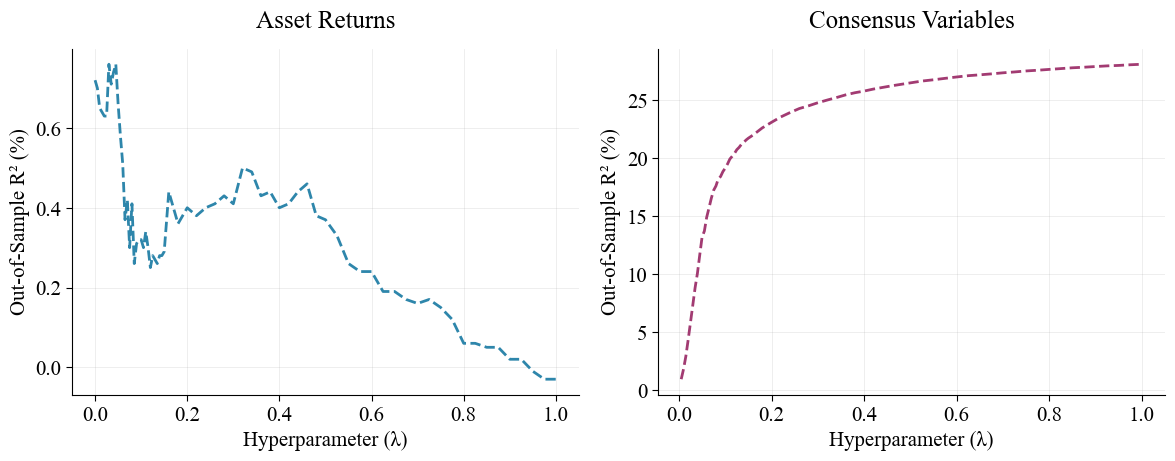


Plotting R² for 3-month prediction horizon


,0.000,0.005,0.010,0.015,0.020,0.025,0.030,0.035,0.040,0.045,...,0.775,0.800,0.825,0.850,0.875,0.900,0.925,0.950,0.975,1.000
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
EPS forecast revision,-3.21,-0.110000,0.100000,0.260000,0.370000,0.570000,0.680000,0.820000,0.96,1.110000,...,5.340000,5.360000,5.380000,5.400000,5.420000,5.440000,5.46,5.460000,5.480000,5.480000
Change in recommendation,-3.15,-0.490000,-0.200000,-0.120000,-0.090000,-0.060000,-0.050000,-0.040000,-0.03,-0.020000,...,0.060000,0.070000,0.070000,0.060000,0.060000,0.060000,0.06,0.070000,0.070000,0.070000
Change in Forecast and Accrual,-16.68,-0.730000,0.070000,0.460000,0.680000,0.810000,0.970000,1.120000,1.26,1.330000,...,5.250000,5.280000,5.310000,5.290000,5.320000,5.340000,5.35,5.360000,5.380000,5.390000
Long-vs-short EPS forecasts,-1.68,-0.000000,0.430000,0.750000,1.060000,1.330000,1.580000,1.860000,2.13,2.400000,...,10.010000,10.050000,10.070000,10.110000,10.100000,10.120000,10.16,10.160000,10.160000,10.170000
Analyst earnings per share,-3.60,2.930000,4.960000,6.990000,8.610000,10.800000,12.260000,14.330000,16.32,18.800000,...,76.420000,76.640000,76.840000,77.040000,77.210000,77.370000,77.57,77.690000,77.810000,77.940000
EPS Forecast Dispersion,-2.71,1.300000,2.330000,3.100000,3.970000,4.970000,5.760000,6.720000,7.67,8.790000,...,42.120000,42.260000,42.420000,42.560000,42.690000,42.800000,42.95,43.070000,43.220000,43.350000
Earnings forecast revisions,-1.91,0.620000,1.070000,1.510000,1.920000,2.300000,2.650000,2.990000,3.35,3.770000,...,17.730000,17.850000,17.930000,18.030000,18.120000,18.200000,18.29,18.380000,18.450000,18.520000
Analyst Value,-3.04,1.500000,2.320000,3.180000,3.920000,4.610000,5.350000,6.230000,7.15,7.760000,...,39.300000,39.520000,39.710000,39.970000,40.190000,40.360000,40.56,40.730000,40.870000,41.050000
Analyst Optimism,-1.97,0.640000,1.460000,2.270000,3.060000,3.900000,4.690000,5.580000,6.55,7.570000,...,41.020000,41.210000,41.360000,41.610000,41.810000,41.990000,42.15,42.270000,42.390000,42.510000


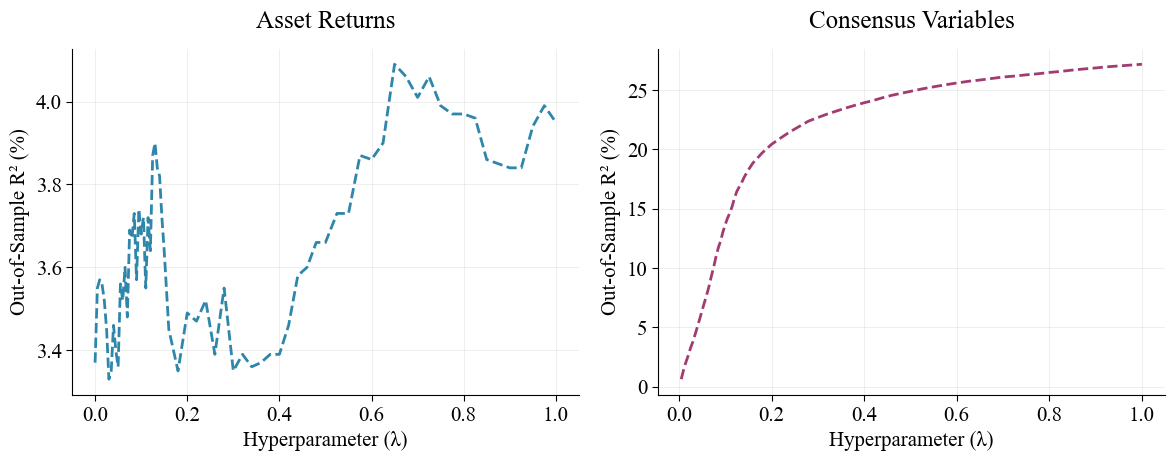


Plotting R² for 6-month prediction horizon


,0.000,0.005,0.010,0.015,0.020,0.025,0.030,0.035,0.040,0.045,...,0.775,0.800,0.825,0.850,0.875,0.900,0.925,0.950,0.975,1.000
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
EPS forecast revision,-5.73,-1.290000,-0.30,0.11,0.32,0.510000,0.620000,0.760000,0.850000,0.960000,...,5.060000,5.110000,5.140000,5.160000,5.190000,5.210000,5.250000,5.270000,5.290000,5.32
Change in recommendation,-7.52,-1.820000,-0.58,-0.45,-0.27,-0.250000,-0.220000,-0.190000,-0.180000,-0.170000,...,-0.050000,-0.050000,-0.040000,-0.040000,-0.040000,-0.040000,-0.030000,-0.030000,-0.020000,-0.02
Change in Forecast and Accrual,-50.01,-6.900000,-1.61,-0.41,0.22,0.500000,0.730000,0.920000,1.050000,1.200000,...,4.940000,4.990000,5.020000,5.040000,5.070000,5.100000,5.130000,5.140000,5.160000,5.18
Long-vs-short EPS forecasts,-2.90,-0.720000,0.29,0.76,1.11,1.410000,1.620000,1.890000,2.050000,2.290000,...,9.460000,9.530000,9.540000,9.580000,9.620000,9.660000,9.700000,9.740000,9.750000,9.76
Analyst earnings per share,-6.11,2.780000,5.89,7.86,9.37,10.910000,12.100000,13.330000,14.620000,16.070000,...,74.120000,74.420000,74.670000,74.880000,75.130000,75.420000,75.670000,75.840000,76.010000,76.15
EPS Forecast Dispersion,-3.96,0.070000,2.77,3.81,4.86,5.740000,6.460000,7.150000,7.770000,8.240000,...,40.400000,40.560000,40.780000,40.920000,41.030000,41.230000,41.400000,41.530000,41.570000,41.67
Earnings forecast revisions,-11.58,-0.160000,1.24,1.97,2.42,2.890000,3.270000,3.580000,3.900000,4.190000,...,16.750000,16.900000,16.990000,17.080000,17.210000,17.310000,17.450000,17.540000,17.650000,17.75
Analyst Value,-10.97,0.990000,2.28,2.98,3.67,4.240000,4.760000,5.320000,5.750000,6.310000,...,37.000000,37.270000,37.540000,37.760000,37.950000,38.200000,38.410000,38.560000,38.740000,38.89
Analyst Optimism,-4.76,0.770000,1.81,2.90,3.86,4.590000,5.200000,5.830000,6.350000,6.940000,...,38.860000,39.080000,39.290000,39.470000,39.700000,39.920000,40.110000,40.260000,40.400000,40.56


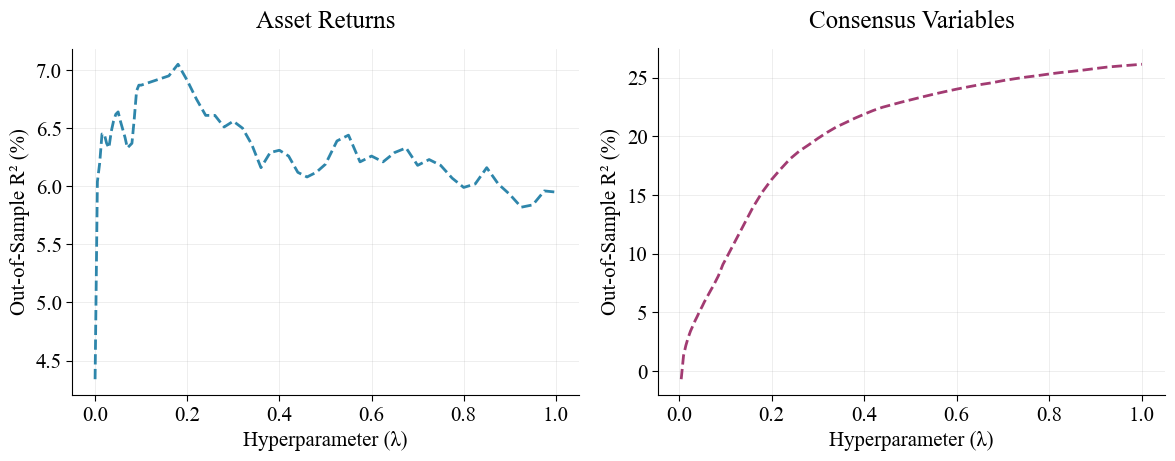


Plotting R² for 12-month prediction horizon


,0.000,0.005,0.010,0.015,0.020,0.025,0.030,0.035,0.040,0.045,...,0.775,0.800,0.825,0.850,0.875,0.900,0.925,0.950,0.975,1.000
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
EPS forecast revision,-5.96,-2.870000,-1.08,-0.370000,-0.120000,0.040000,0.190000,0.330000,0.430000,0.540000,...,4.660000,4.710000,4.74,4.770000,4.800000,4.850000,4.88,4.900000,4.930000,4.970000
Change in recommendation,-9.96,-3.860000,-1.95,-1.350000,-1.080000,-0.890000,-0.720000,-0.570000,-0.460000,-0.410000,...,-0.180000,-0.160000,-0.16,-0.160000,-0.160000,-0.170000,-0.15,-0.160000,-0.160000,-0.160000
Change in Forecast and Accrual,-49.33,-15.830000,-6.61,-3.320000,-2.020000,-1.200000,-0.550000,-0.060000,0.270000,0.520000,...,4.250000,4.310000,4.36,4.400000,4.430000,4.500000,4.52,4.550000,4.580000,4.620000
Long-vs-short EPS forecasts,-5.70,-1.630000,-0.66,-0.110000,0.270000,0.600000,0.880000,1.130000,1.340000,1.510000,...,8.590000,8.660000,8.71,8.760000,8.810000,8.890000,8.95,8.990000,9.040000,9.120000
Analyst earnings per share,-2.55,1.600000,3.38,4.930000,6.390000,7.760000,8.980000,9.930000,10.810000,11.710000,...,68.110000,68.550000,68.94,69.240000,69.520000,70.390000,70.60,70.830000,71.080000,71.430000
EPS Forecast Dispersion,-5.98,-1.330000,0.95,2.050000,2.820000,3.590000,4.370000,5.070000,5.600000,6.260000,...,37.160000,37.400000,37.61,37.800000,38.000000,38.440000,38.55,38.700000,38.860000,39.060000
Earnings forecast revisions,-11.15,-3.260000,-0.99,0.120000,0.630000,1.190000,1.760000,2.090000,2.470000,2.800000,...,14.950000,15.080000,15.22,15.350000,15.450000,15.730000,15.82,15.950000,16.060000,16.180000
Analyst Value,-11.57,-1.860000,0.63,1.880000,2.490000,3.100000,3.640000,4.180000,4.510000,4.940000,...,32.990000,33.340000,33.62,33.900000,34.120000,34.650000,34.81,34.990000,35.200000,35.450000
Analyst Optimism,-5.12,-0.780000,1.02,2.320000,3.090000,3.750000,4.290000,4.700000,5.040000,5.470000,...,35.020000,35.320000,35.58,35.800000,36.020000,36.530000,36.67,36.830000,37.020000,37.240000


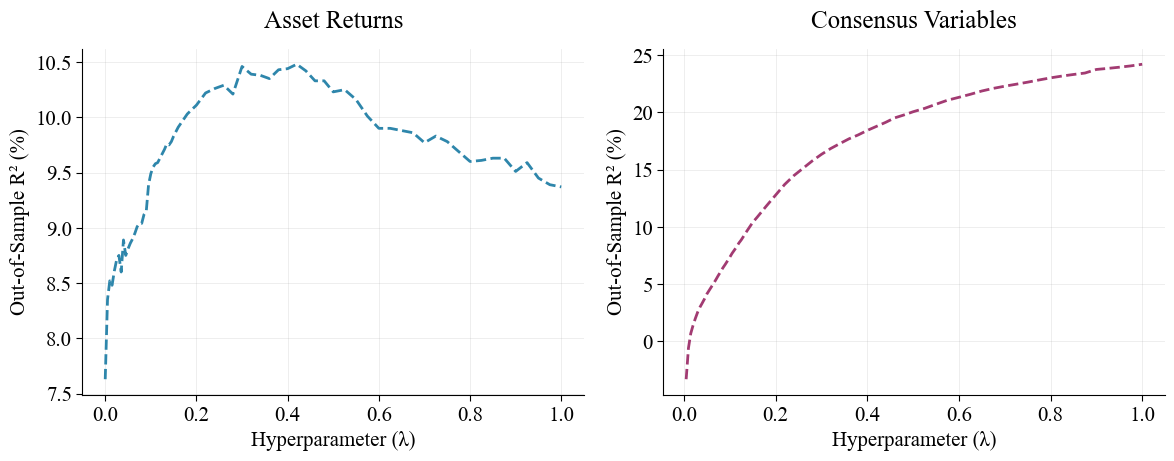

In [11]:
print("\nPlotting R² for 1-month prediction horizon")
plot_r_squared(horizon='1month')

print("\nPlotting R² for 3-month prediction horizon")
plot_r_squared(horizon='3month')

print("\nPlotting R² for 6-month prediction horizon")
plot_r_squared(horizon='6month')

print("\nPlotting R² for 12-month prediction horizon")
plot_r_squared(horizon='12month')

### R-Squared by period

Plotting R² for 1-month prediction horizon


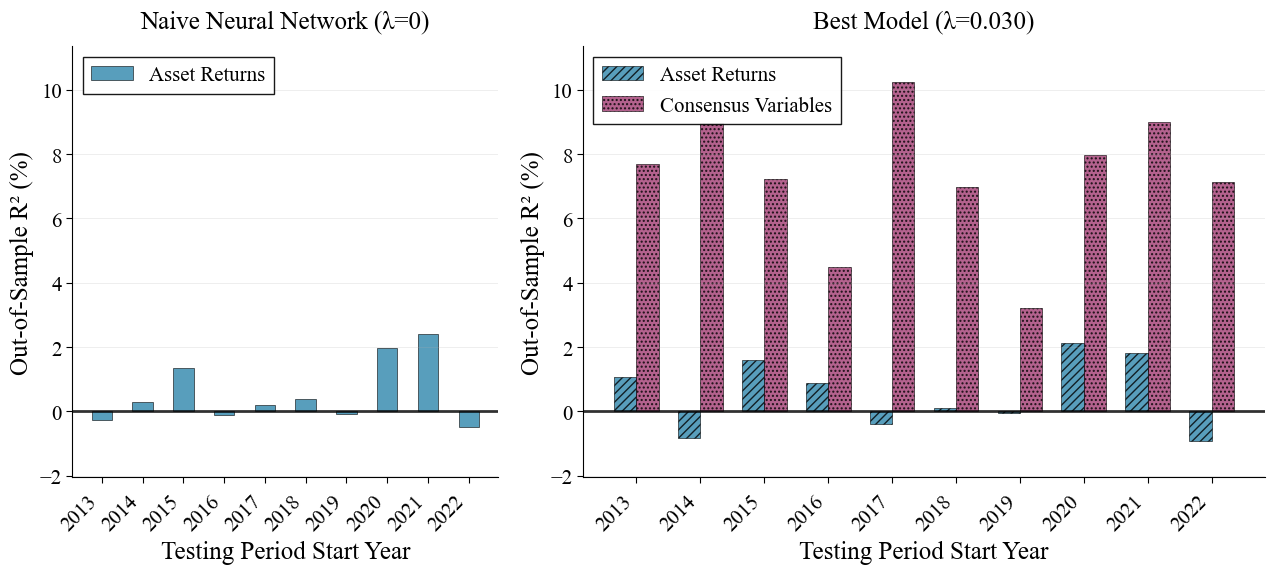

Plotting R² for 3-month prediction horizon


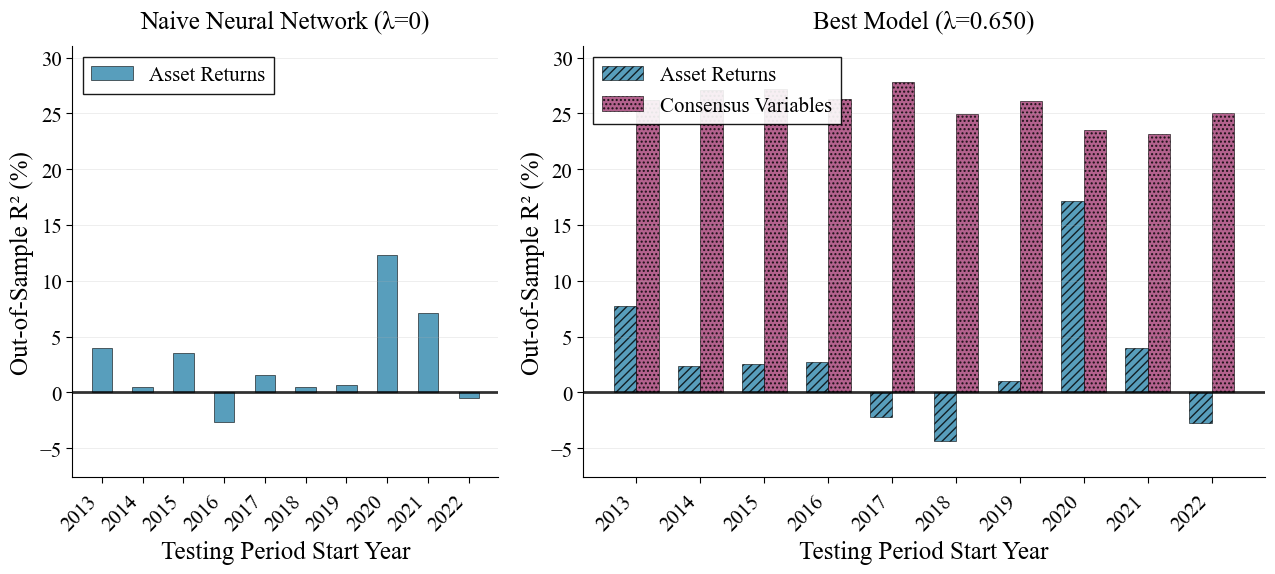

Plotting R² for 6-month prediction horizon


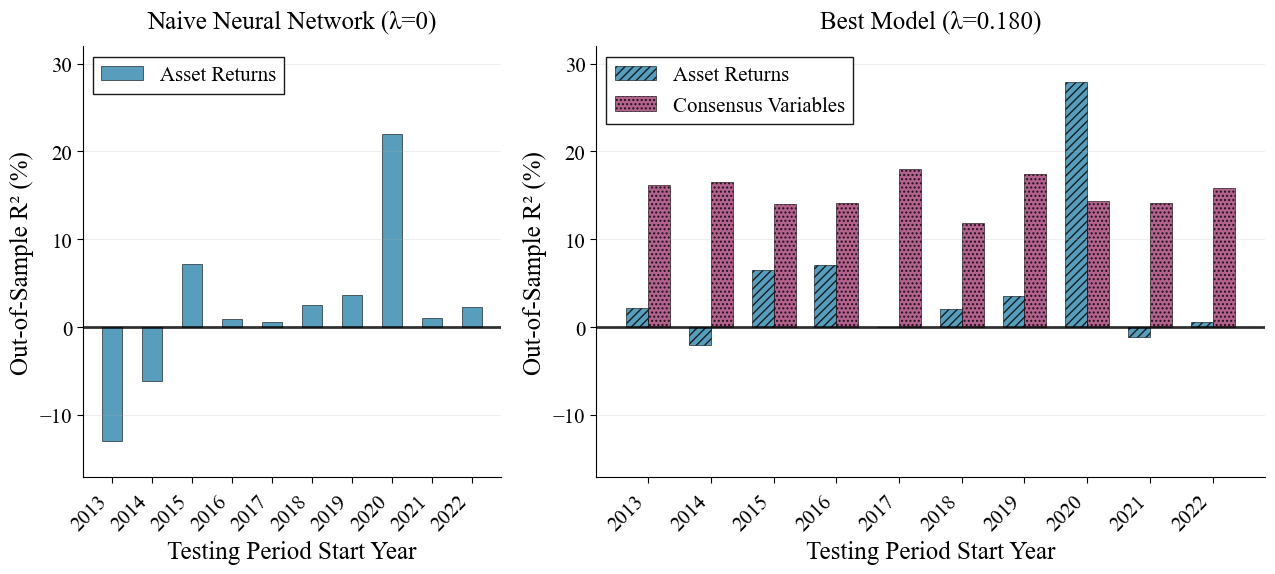

Plotting R² for 12-month prediction horizon


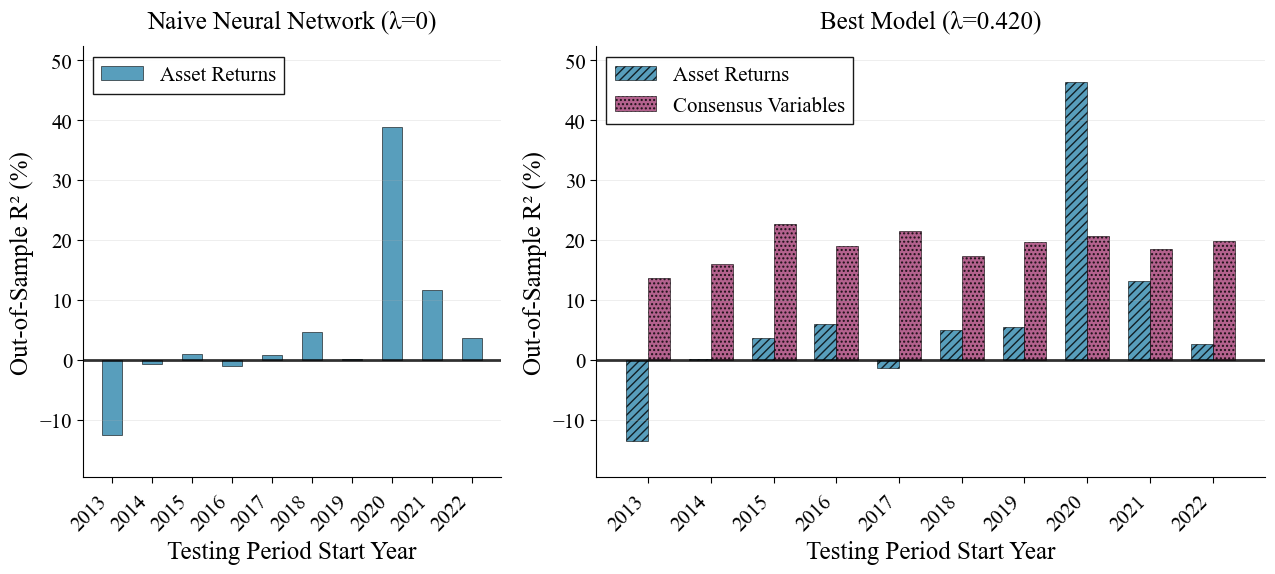

In [15]:
columns = ['2014-01-01', '2015-01-01', '2016-01-01', '2017-01-01', '2018-01-01', '2019-01-01', '2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01']
index_name = ['2013-01-01~2013-12-31', '2014-01-01~2014-12-31', '2015-01-01~2015-12-31','2016-01-01~2016-12-31', '2017-01-01~2017-12-31', 
              '2018-01-01~2018-12-31', '2019-01-01~2019-12-31', '2020-01-01~2020-12-31', '2021-01-01~2021-12-31', '2022-01-01~2022-12-31']

print("Plotting R² for 1-month prediction horizon")
plot_r_squared_by_period(columns, index_name, horizon='1month')

print("Plotting R² for 3-month prediction horizon")
plot_r_squared_by_period(columns, index_name, horizon='3month')

print("Plotting R² for 6-month prediction horizon")
plot_r_squared_by_period(columns, index_name, horizon='6month')

print("Plotting R² for 12-month prediction horizon")
plot_r_squared_by_period(columns, index_name, horizon='12month')